[![Fixel Algorithms](https://i.imgur.com/AqKHVZ0.png)](https://fixelalgorithms.gitlab.io/)

# AI Program

## Essential Linear Algebra - The $ {L}^{p} $ Norm

> Notebook by:
> - Royi Avital RoyiAvital@fixelalgorithms.com

## Revision History

| Version | Date       | User        | Content / Changes                                                  |
|---------|------------|-------------|--------------------------------------------------------------------|
| 1.0.003 | 19/10/2025 | Royi Avital | Code refinement                                                    |
| 1.0.002 | 03/12/2024 | Royi Avital | The drawing function returns `plt.Figure`                          |
| _______ | __________ | ___________ | Using `np.inf` to support NumPy `2.x`                              |
| 1.0.001 | 13/09/2024 | Royi Avital | Fixed issues with non raw strings in the unit ball function        |
| _______ | __________ | ___________ | Definition of the _unit sphere_                                    |
| 1.0.000 | 10/01/2024 | Royi Avital | First version                                                      |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FixelAlgorithmsTeam/FixelCourses/blob/master/AIProgram/2024_02/0001LpNorm.ipynb)

In [1]:
# Import Packages

# General Tools
import numpy as np
import scipy as sp
import pandas as pd

# Miscellaneous
import os
from platform import python_version
import random

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Typing
from typing import Any, Callable, List, Tuple, Union
from numpy.typing import NDArray

# Jupyter
from IPython import get_ipython
from IPython.display import Image, display
from ipywidgets import Dropdown, FloatSlider, interact, IntSlider, Layout

## Notations

* <font color='red'>(**?**)</font> Question to answer interactively.
* <font color='blue'>(**!**)</font> Simple task to add code for the notebook.
* <font color='green'>(**@**)</font> Optional / Extra self practice.
* <font color='brown'>(**#**)</font> Note / Useful resource / Food for thought.

Code Notations:

```python
someVar    = 2; #<! Notation for a variable
vVector    = np.random.rand(4) #<! Notation for 1D array
mMatrix    = np.random.rand(4, 3) #<! Notation for 2D array
tTensor    = np.random.rand(4, 3, 2, 3) #<! Notation for nD array (Tensor)
tuTuple    = (1, 2, 3) #<! Notation for a tuple
lList      = [1, 2, 3] #<! Notation for a list
dDict      = {1: 3, 2: 2, 3: 1} #<! Notation for a dictionary
oObj       = MyClass() #<! Notation for an object
dfData     = pd.DataFrame() #<! Notation for a data frame
dsData     = pd.Series() #<! Notation for a series
hObj       = plt.Axes() #<! Notation for an object / handler / function handler
```

### Code Exercise

 - Single line fill

```python
valToFill = ???
```

 - Multi Line to Fill (At least one)

```python
# You need to start writing
?????
```

 - Section to Fill

```python
#===========================Fill This===========================#
# 1. Explanation about what to do.
# !! Remarks to follow / take under consideration.
mX = ???

?????
#===============================================================#
```

In [2]:
# Configuration
# %matplotlib inline

# warnings.filterwarnings("ignore")

seedNum = 512
np.random.seed(seedNum)
random.seed(seedNum)

# Matplotlib default color palette
lMatPltLibclr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_theme() #>! Apply SeaBorn theme
# sns.set_palette("tab10")

runInGoogleColab = 'google.colab' in str(get_ipython())

In [3]:
# Constants

FIG_SIZE_DEF    = (8, 8)
ELM_SIZE_DEF    = 50
CLASS_COLOR     = ('b', 'r')
EDGE_COLOR      = 'k'
MARKER_SIZE_DEF = 10
LINE_WIDTH_DEF  = 2

In [4]:
# Course Packages


In [5]:
# Auxiliary Functions



In [6]:
# Parameters

# Grid
lowerBound = -1.5
upperBound = 1.5
numGridPts = 500

## Generate Data


### Create 1D Grid

In [7]:
# Generate 1D Grid

vG = np.linspace(lowerBound, upperBound, numGridPts) #<! Linear steps grid

print(f'The Grid Shape: {vG.shape}')

The Grid Shape: (500,)


### Create 2D Grid

In [8]:
# Created 2D Grid

mX1, mX2 = np.meshgrid(vG, vG)

print(f'The Grid Shape: {mX1.shape}, {mX2.shape}')

The Grid Shape: (500, 500), (500, 500)


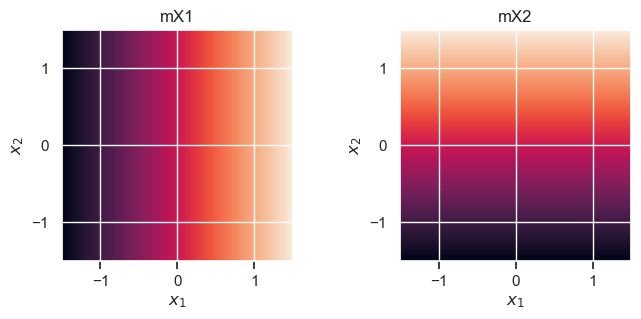

In [9]:
# Plot the 2D Grid

# Use Tuple when no need for mutability
tuXX    = (mX1, mX2)
tuTitle = ('mX1', 'mX2')

hF, _ = plt.subplots(1, 2, figsize = (8, 3))
for ii, hA in enumerate(hF.axes):
    hA.matshow(tuXX[ii], extent = (vG[0], vG[-1], vG[0], vG[-1]), origin = 'lower')
    hA.set_title(tuTitle[ii])
    hA.set_xlabel('$x_1$')
    hA.set_ylabel('$x_2$')
    hA.xaxis.tick_bottom()

plt.show()

In [10]:
# Creating the Grid as 2 Vectors
mX = np.stack([mX1.flatten(), mX2.flatten()])
print(f'The Flatten Grid Shape: {mX.shape}')

The Flatten Grid Shape: (2, 250000)


## The ${L}^{p}$ Norm

$$ {\left\| \boldsymbol{x} \right\|}_{p} = \sqrt[p]{\sum_{i = 1}^{d} {\left| {x}_{i} \right|}^{p}} \Rightarrow {\left\| \boldsymbol{x} \right\|}_{p}^{p} = \sum_{i = 1}^{d} {\left| {x}_{i} \right|}^{p} $$

In [11]:
# Defining the Lp Norm as a Function

def LpNorm(mX: NDArray, p: int):
    
    return np.sum(np.abs(mX) ** p, axis = 0) #<! ||x||ₚᵖ

In [12]:
# Plotting the Lp Norm Unit Ball

def PlotLpNormUnitBall(mX: NDArray, mX1: NDArray, mX2: NDArray, p: int = 2, figSize: Tuple[int, int] = FIG_SIZE_DEF) -> plt.Figure:
    if p >= 5:
        p = np.inf
    
    # Binary Map of the Unit Ball (Interior)
    mZ = LpNorm(mX, p) <= 1
    mZ = mZ.reshape(mX1.shape)
        
    # Color
    tuCyan  = (0.00, 0.75, 0.75)
    tuRed   = (0.75, 0.00, 0.00)
    tuWhite = (1.00, 1.00, 1.00)
    tuColor = tuCyan if p >= 1 else tuRed
    
    # Title:
    # pStr = '\infty' if np.isinf(p) else str(p)

    if np.isinf(p):
        pStr = r'\infty'
    else:
        if int(p) == p:
            pStr = str(p)
        else:
            pStr = f'{p:0.2f}'

    if p % 1 < 0.001:
        pStr = f'{p:.0f}' #<! round integer

    # Plot
    hF, hA = plt.subplots(figsize = figSize)
    hA.grid(True, linestyle = '--', linewidth = .3)
    hA.axhline(y = 0, color = 'k', linewidth = 3)
    hA.axvline(x = 0, color = 'k', linewidth = 3)
    hA.contourf(mX1, mX2, (2 * mZ) - 1, colors = [(1, 1, 1), tuColor], alpha = 0.75)
    hA.set_title(r'${\left\| \boldsymbol{x} \right\|}_{' + pStr + r'} \leq 1$', fontsize = 18)
    hA.set_xlabel('$x_1$')
    hA.set_ylabel('$x_2$')

    # return hF #<! Returning the figure generates 2 output in `interact()`

### The ${L}^{p}$ Norm Unit Ball

 * The _unit ball_ is defined as $\mathcal{B}_{p} = \left\{ \boldsymbol{x} \mid {\left\| \boldsymbol{x} \right\|}_{p} \leq 1 \right\}$.  
 * The _unit sphere_ is defined as: $\mathcal{S}_{p} = \left\{ \boldsymbol{x} \mid {\left\| \boldsymbol{x} \right\|}_{p} = 1 \right\}$.

In [ ]:
# Interactive Plot of the Unit Ball Interior

hPlotLpNormUnitBall = lambda p: PlotLpNormUnitBall(mX, mX1, mX2, p, (6, 6))
pSlider = FloatSlider(min = 0.25, max = 5.00, step = 0.25, value = 1.00, readout = False, continuous_update = False, readout_format = '.2f', layout = Layout(width = '30%'))
interact(hPlotLpNormUnitBall, p = pSlider);

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='p', layout=Layout(width='30…